# IV Drop Detection - YOLOv8 Training

This notebook implements a complete workflow to train a YOLOv8 object detection model for detecting IV fluid drops in images.

**Architecture:** YOLOv8 Nano (YOLOv8n) - a state-of-the-art object detection model optimized for speed and accuracy  
**Dataset:** 3,458 annotated images with bounding box labels

The YOLOv8 model learns to detect drops by predicting bounding boxes around them, providing both detection and localization capabilities in a single pass.

### 1. Installing Required Dependencies

This cell installs the Ultralytics library, which provides the YOLOv8 implementation. The `--no-deps` flag prevents dependency conflicts, and `--quiet` suppresses verbose output during installation.


In [1]:
!pip install ultralytics --no-deps --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.0 MB/s eta 0:00:00


### 2. Dataset Setup, Training Configuration, and Model Training

This cell performs the complete setup and training pipeline in a single workflow.

**Part 1: Dataset Path Detection**
- Automatically searches for the dataset directory containing `images` and `labels` folders.
- Handles variations in dataset location within Kaggle's input structure.

**Part 2: Data Splitting**
- Splits the dataset into training (80%) and validation (20%) sets using stratified splitting.
- Creates the required directory structure for YOLOv8 format.
- Copies images and corresponding label files to appropriate split directories.
- Handles negative samples (images without drops) by creating empty label files.

**Part 3: YOLOv8 Configuration**
- Creates a YAML configuration file specifying:
    - Dataset paths for training and validation.
    - Number of classes (1: "drop").
    - Class names.

**Part 4: Model Training**
- Loads the pre-trained YOLOv8 Nano model (yolov8n.pt) for transfer learning.
- Trains with the following hyperparameters:
    - Epochs: 100 (with early stopping patience of 15).
    - Image size: 640x640 pixels.
    - Batch size: 16.
- Saves checkpoints and training results automatically.

**Part 5: Initial Results Visualization**
- Displays the best mAP50 (mean Average Precision at IoU=0.5) achieved during training.
- Visualizes predictions on sample validation images to quickly assess model performance.


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Found dataset at: /kaggle/input/iv-fluids-drop-monitor-dataset-yolov8-heatmap/Drop-detection-heatmaps-yolov8/dataset
Total images found: 3458
Preparing training split...
Preparing validation split...
Starting Training...
Ultralytics 8.3.234 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dyna

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        692        619      0.942      0.942      0.958      0.506
Speed: 0.1ms preprocess, 1.4ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /kaggle/working/runs/detect/drop_detection
Best mAP50: 0.9580300108844434

0: 640x640 2 drops, 12.8ms
1: 640x640 1 drop, 12.8ms
2: 640x640 1 drop, 12.8ms
Speed: 2.3ms preprocess, 12.8ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


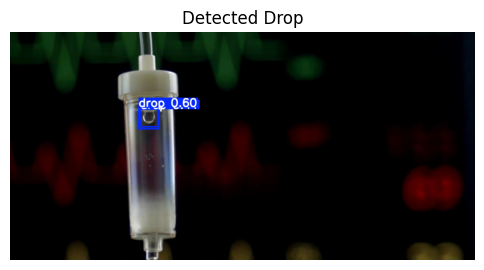

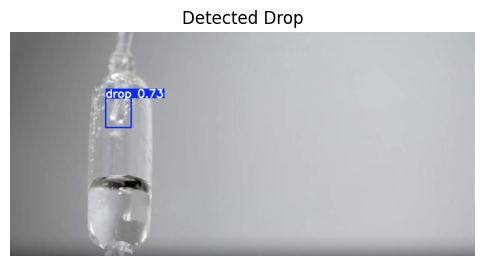

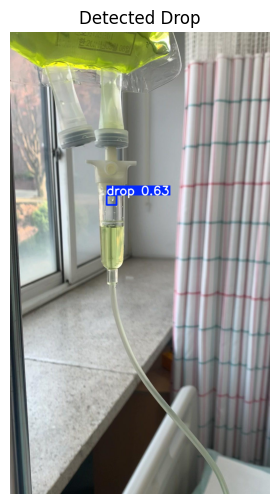

In [2]:
import os
import shutil
import yaml
from glob import glob
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import numpy as np

# =============================================================================
# 1. AUTO-DETECT DATASET PATH
# =============================================================================
# This loop finds where the 'images' and 'labels' folders are hiding
INPUT_ROOT = None
for root, dirs, files in os.walk('/kaggle/input/iv-fluids-drop-monitor-dataset-yolov8-heatmap/Drop-detection-heatmaps-yolov8/dataset'):
    if 'images' in dirs and 'labels' in dirs:
        INPUT_ROOT = root
        print(f"✅ Found dataset at: {INPUT_ROOT}")
        break

if INPUT_ROOT is None:
    raise FileNotFoundError("Could not find a folder containing 'images' and 'labels' in /kaggle/input")

# =============================================================================
# 2. SETUP & SPLIT DATA
# =============================================================================
WORKING_DIR = '/kaggle/working/dataset_split'
VAL_SIZE = 0.2
SEED = 42

# Create directories
for split in ['train', 'val']:
    for kind in ['images', 'labels']:
        os.makedirs(os.path.join(WORKING_DIR, split, kind), exist_ok=True)

# Get all images
src_images_dir = os.path.join(INPUT_ROOT, 'images')
src_labels_dir = os.path.join(INPUT_ROOT, 'labels')
image_files = []
for ext in ['*.jpg', '*.jpeg', '*.png', '*.bmp']:
    image_files.extend(glob(os.path.join(src_images_dir, ext)))

print(f"Total images found: {len(image_files)}")

# Split
train_files, val_files = train_test_split(image_files, test_size=VAL_SIZE, random_state=SEED)

def copy_dataset(files, split_name):
    dest_img = os.path.join(WORKING_DIR, split_name, 'images')
    dest_lbl = os.path.join(WORKING_DIR, split_name, 'labels')
    
    for img_path in files:
        filename = os.path.basename(img_path)
        
        # Copy Image
        shutil.copy(img_path, os.path.join(dest_img, filename))
        
        # Handle Label
        label_name = os.path.splitext(filename)[0] + '.txt'
        src_label_path = os.path.join(src_labels_dir, label_name)
        dest_label_path = os.path.join(dest_lbl, label_name)
        
        if os.path.exists(src_label_path):
            shutil.copy(src_label_path, dest_label_path)
        else:
            # Create empty file for negative samples (no drop)
            with open(dest_label_path, 'w') as f:
                pass

print("Preparing training split...")
copy_dataset(train_files, 'train')
print("Preparing validation split...")
copy_dataset(val_files, 'val')

# =============================================================================
# 3. CREATE CONFIG & TRAIN
# =============================================================================
yaml_content = f"""
path: {WORKING_DIR} 
train: train/images
val: val/images
nc: 1
names: ['drop']
"""

with open('/kaggle/working/data.yaml', 'w') as f:
    f.write(yaml_content)

print("Starting Training...")

# Load Nano model
model = YOLO('yolov8n.pt') 

# Train
results = model.train(
    data='/kaggle/working/data.yaml', 
    epochs=100,             
    patience=15,            # Early stopping
    imgsz=640,              
    batch=16,               
    name='drop_detection',
    project='/kaggle/working/runs/detect',
    exist_ok=True
)

# =============================================================================
# 4. VISUALIZE RESULTS
# =============================================================================
print(f"Best mAP50: {results.box.map50}")

# Get 3 random validation images
val_imgs = glob(os.path.join(WORKING_DIR, 'val', 'images', '*'))[:3]

if val_imgs:
    preds = model.predict(val_imgs, conf=0.25)
    for p in preds:
        plt.figure(figsize=(6,6))
        plt.imshow(cv2.cvtColor(p.plot(), cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title("Detected Drop")
        plt.show()

### 3. Loading the Best Trained Model

After training completes, YOLOv8 automatically saves the best model checkpoint (lowest validation loss). This cell loads that best model for subsequent evaluation and inference tasks.

The model is loaded from the standard YOLOv8 output directory structure, where `weights/best.pt` contains the best performing model weights. This ensures we use the most accurate model for all downstream tasks.


In [3]:
from ultralytics import YOLO
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image, display

# Define the path to the best model
# Note: Check your "runs" folder structure if this path fails, but this is the standard yolov8 path
best_model_path = '/kaggle/working/runs/detect/drop_detection/weights/best.pt'

# Load the best model
model = YOLO(best_model_path)

print(f"Loaded model from: {best_model_path}")

Loaded model from: /kaggle/working/runs/detect/drop_detection/weights/best.pt


### 4. Visualizing Training Results

YOLOv8 automatically generates comprehensive training plots during the training process. This cell displays the main results visualization.

**Training Results Plot (`results.png`):**
- Contains multiple subplots showing:
    - Training and validation loss curves (box loss, classification loss, DFL loss).
    - Precision and recall metrics over epochs.
    - mAP50 and mAP50-95 metrics over epochs.
    - Learning rate schedule.

This visualization provides a quick overview of the training process, helping identify:
- Whether the model converged properly.
- If overfitting occurred (large gap between training and validation metrics).
- The best epoch for model selection.
- Overall training stability.


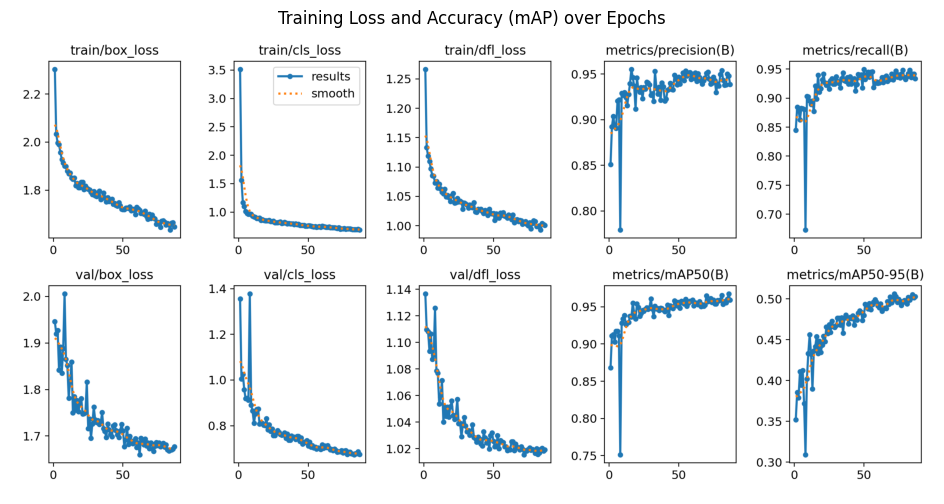

In [4]:
# Path to results.png
results_path = '/kaggle/working/runs/detect/drop_detection/results.png'

if os.path.exists(results_path):
    plt.figure(figsize=(12, 6))
    img = mpimg.imread(results_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title("Training Loss and Accuracy (mAP) over Epochs")
    plt.show()
else:
    print("results.png not found yet.")

### 5. Confusion Matrix Visualization

This cell displays the confusion matrix generated by YOLOv8 during training or validation.

**Confusion Matrix:**
- Shows the model's classification performance in a 2x2 grid format.
- Rows represent true labels (Background vs. Drop).
- Columns represent predicted labels.
- Diagonal elements show correct predictions.
- Off-diagonal elements show misclassifications.

The confusion matrix helps understand:
- How well the model distinguishes between drops and background.
- Common error patterns (false positives, false negatives).
- Overall detection accuracy.

This visualization is crucial for understanding model behavior and identifying areas for improvement.


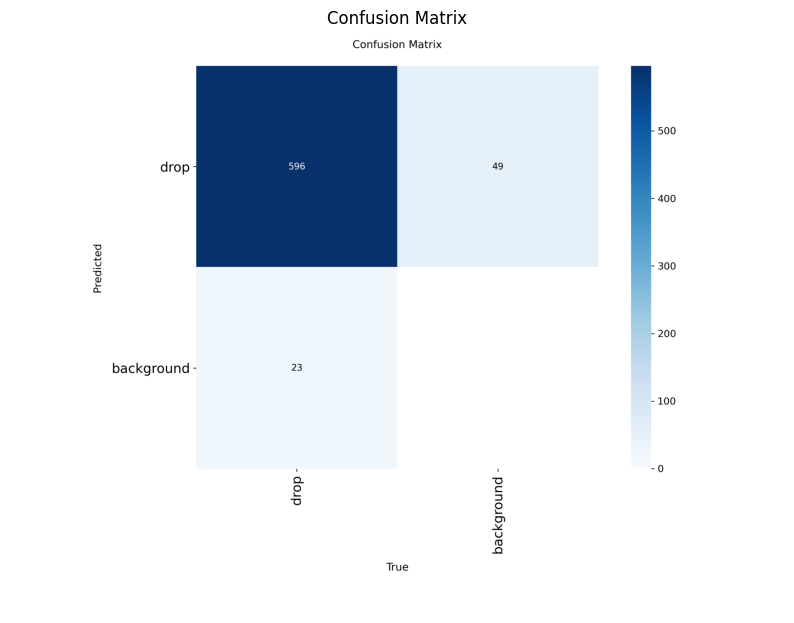

In [5]:
# Path to confusion matrix
cm_path = '/kaggle/working/runs/detect/drop_detection/confusion_matrix.png'

if os.path.exists(cm_path):
    plt.figure(figsize=(10, 8))
    img = mpimg.imread(cm_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title("Confusion Matrix")
    plt.show()
else:
    # Sometimes it's named differently in newer versions or normalization settings
    print("Confusion matrix file not found. It might be named confusion_matrix_normalized.png")
    cm_norm_path = '/kaggle/working/runs/detect/drop_detection/confusion_matrix_normalized.png'
    if os.path.exists(cm_norm_path):
        display(Image(filename=cm_norm_path))

### 6. Comprehensive Prediction Visualization

This cell provides detailed visualizations of the model's predictions on validation data.

**Part 1: Pre-generated Validation Batches**
- Displays YOLOv8's automatically generated validation batch visualizations.
- Shows ground truth labels alongside model predictions for comparison.
- Helps identify systematic errors or patterns in predictions.

**Part 2: Custom Test Sets**
- Generates custom visualizations on unseen validation images.
- Creates multiple sets of 2x2 grids (4 images per set).
- Each image shows:
    - Detected bounding boxes (if any).
    - Confidence scores for detections.
    - Comparison between images with and without drops.

**Benefits:**
- Provides qualitative assessment of model performance.
- Helps understand how the model behaves on diverse samples.
- Useful for identifying edge cases or failure modes.
- Visual validation of model correctness before deployment.


--- Checking for extra training batches (Batch 1, Batch 2) ---


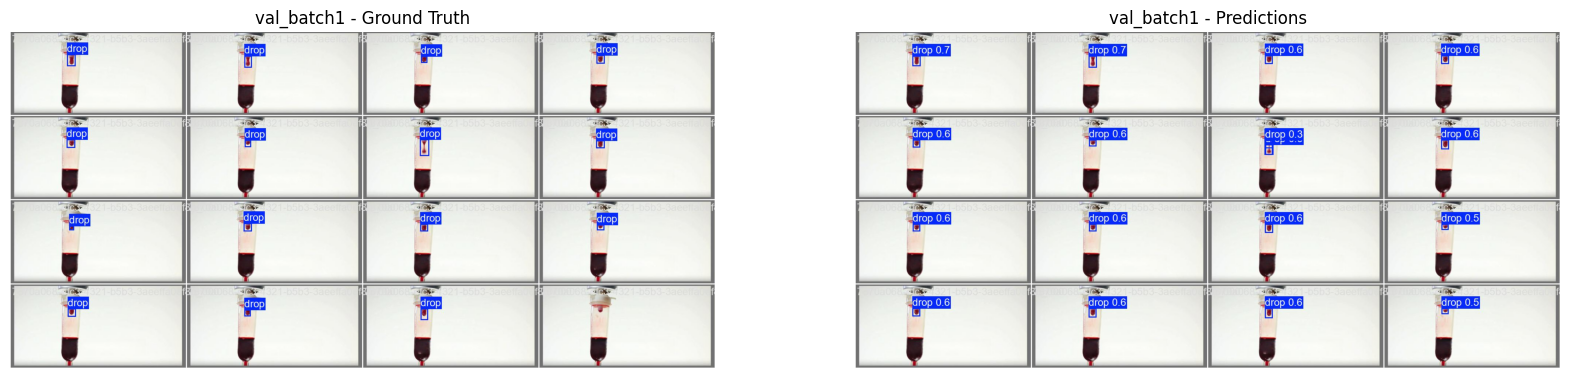

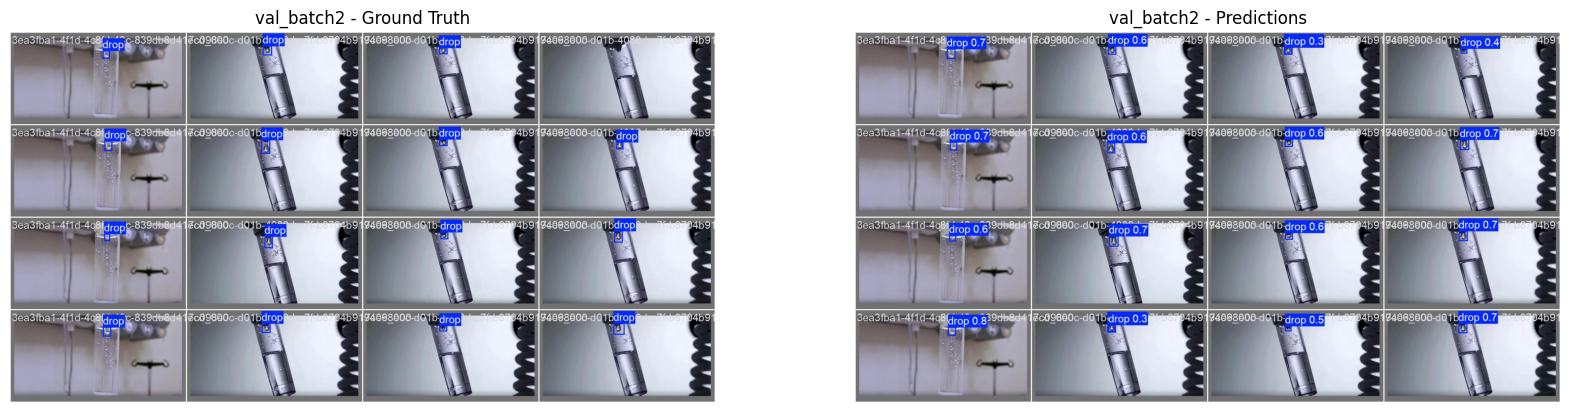

--- Generating Custom Test Sets on Unseen Validation Data ---


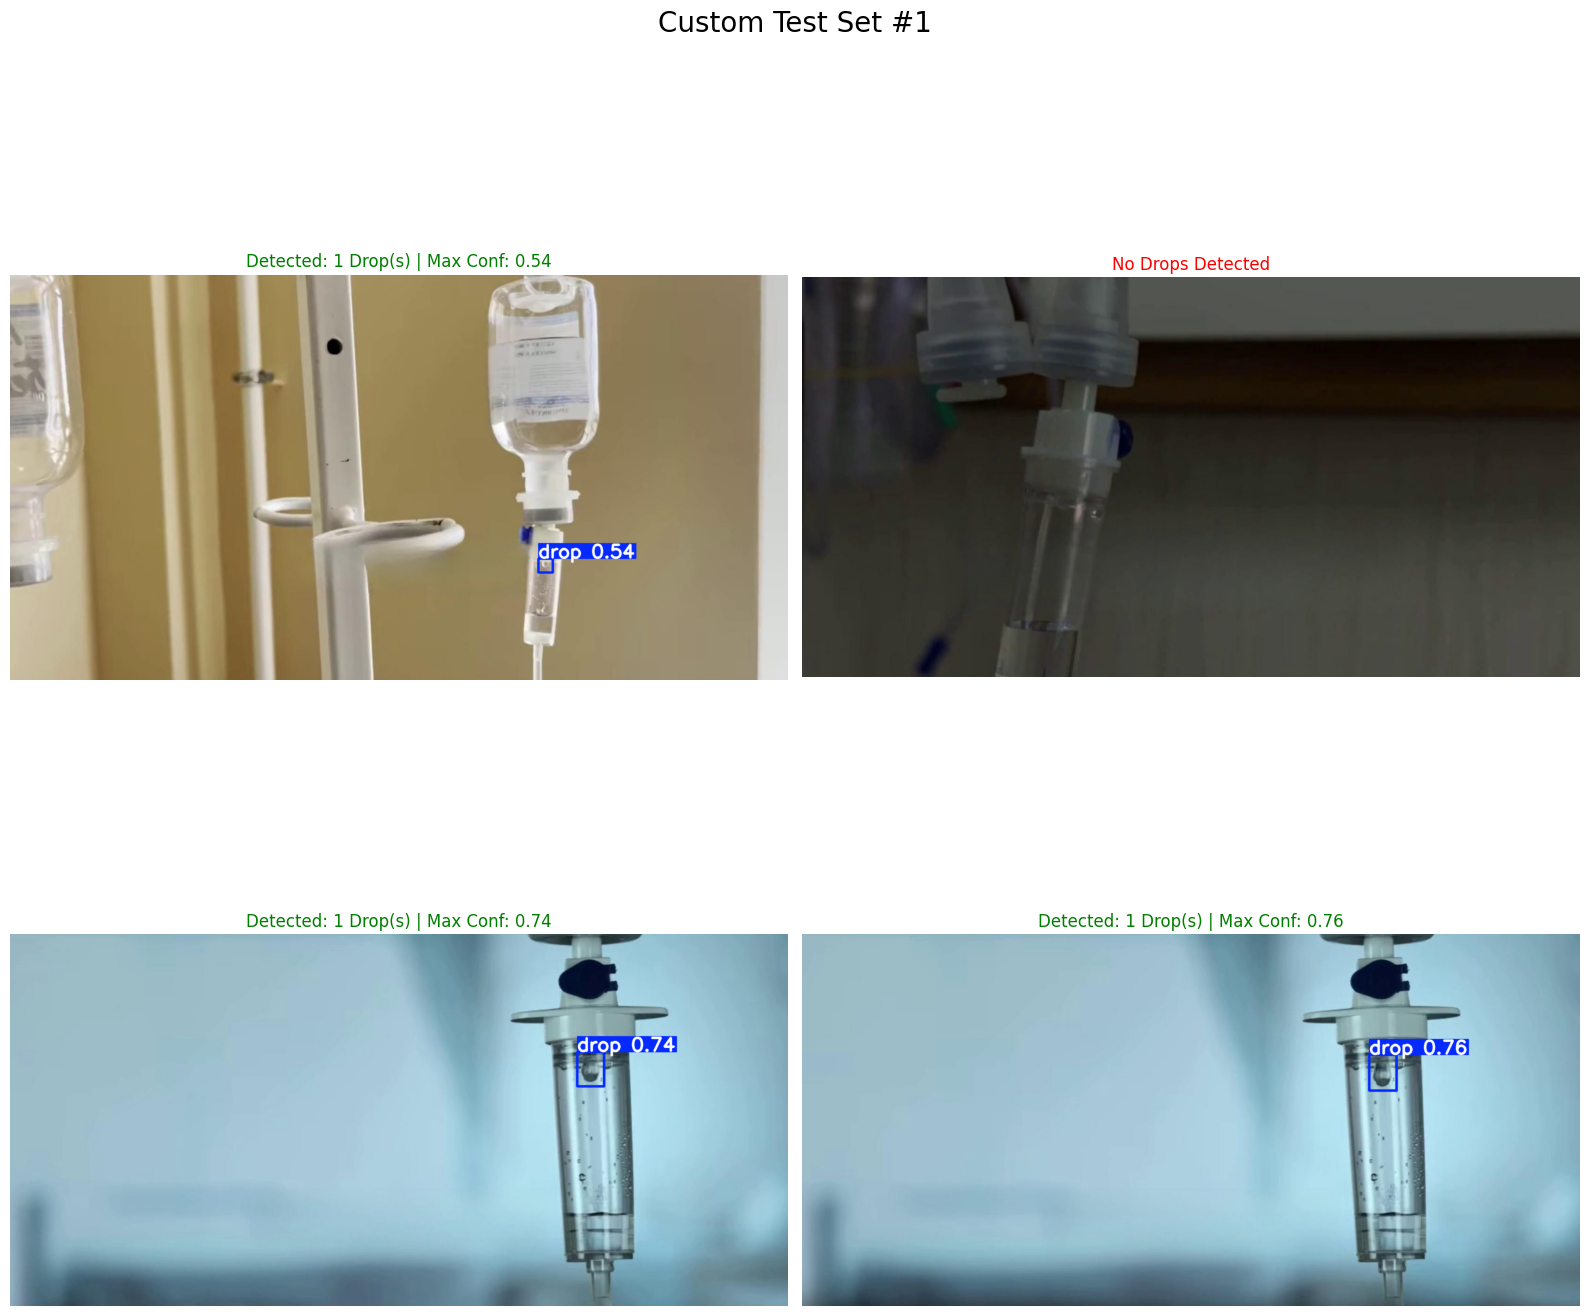

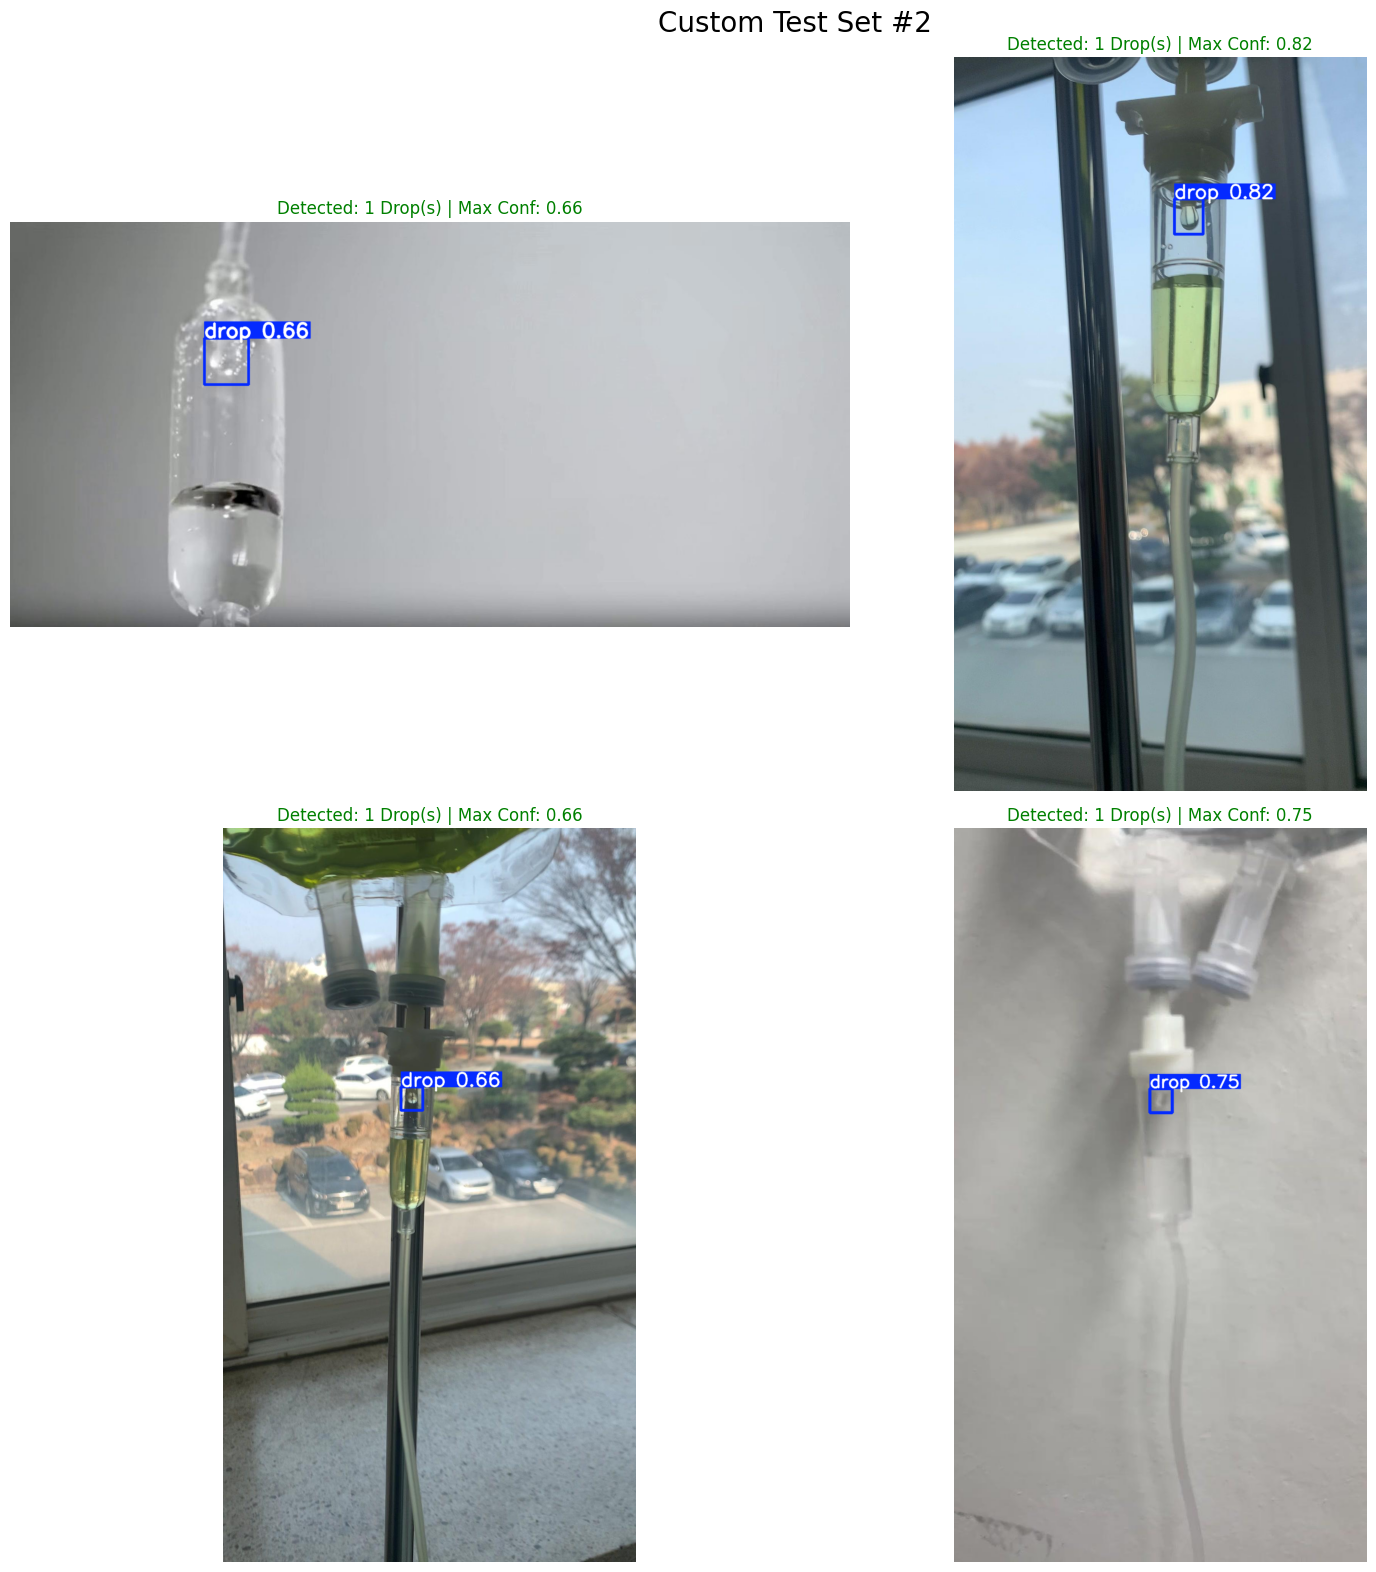

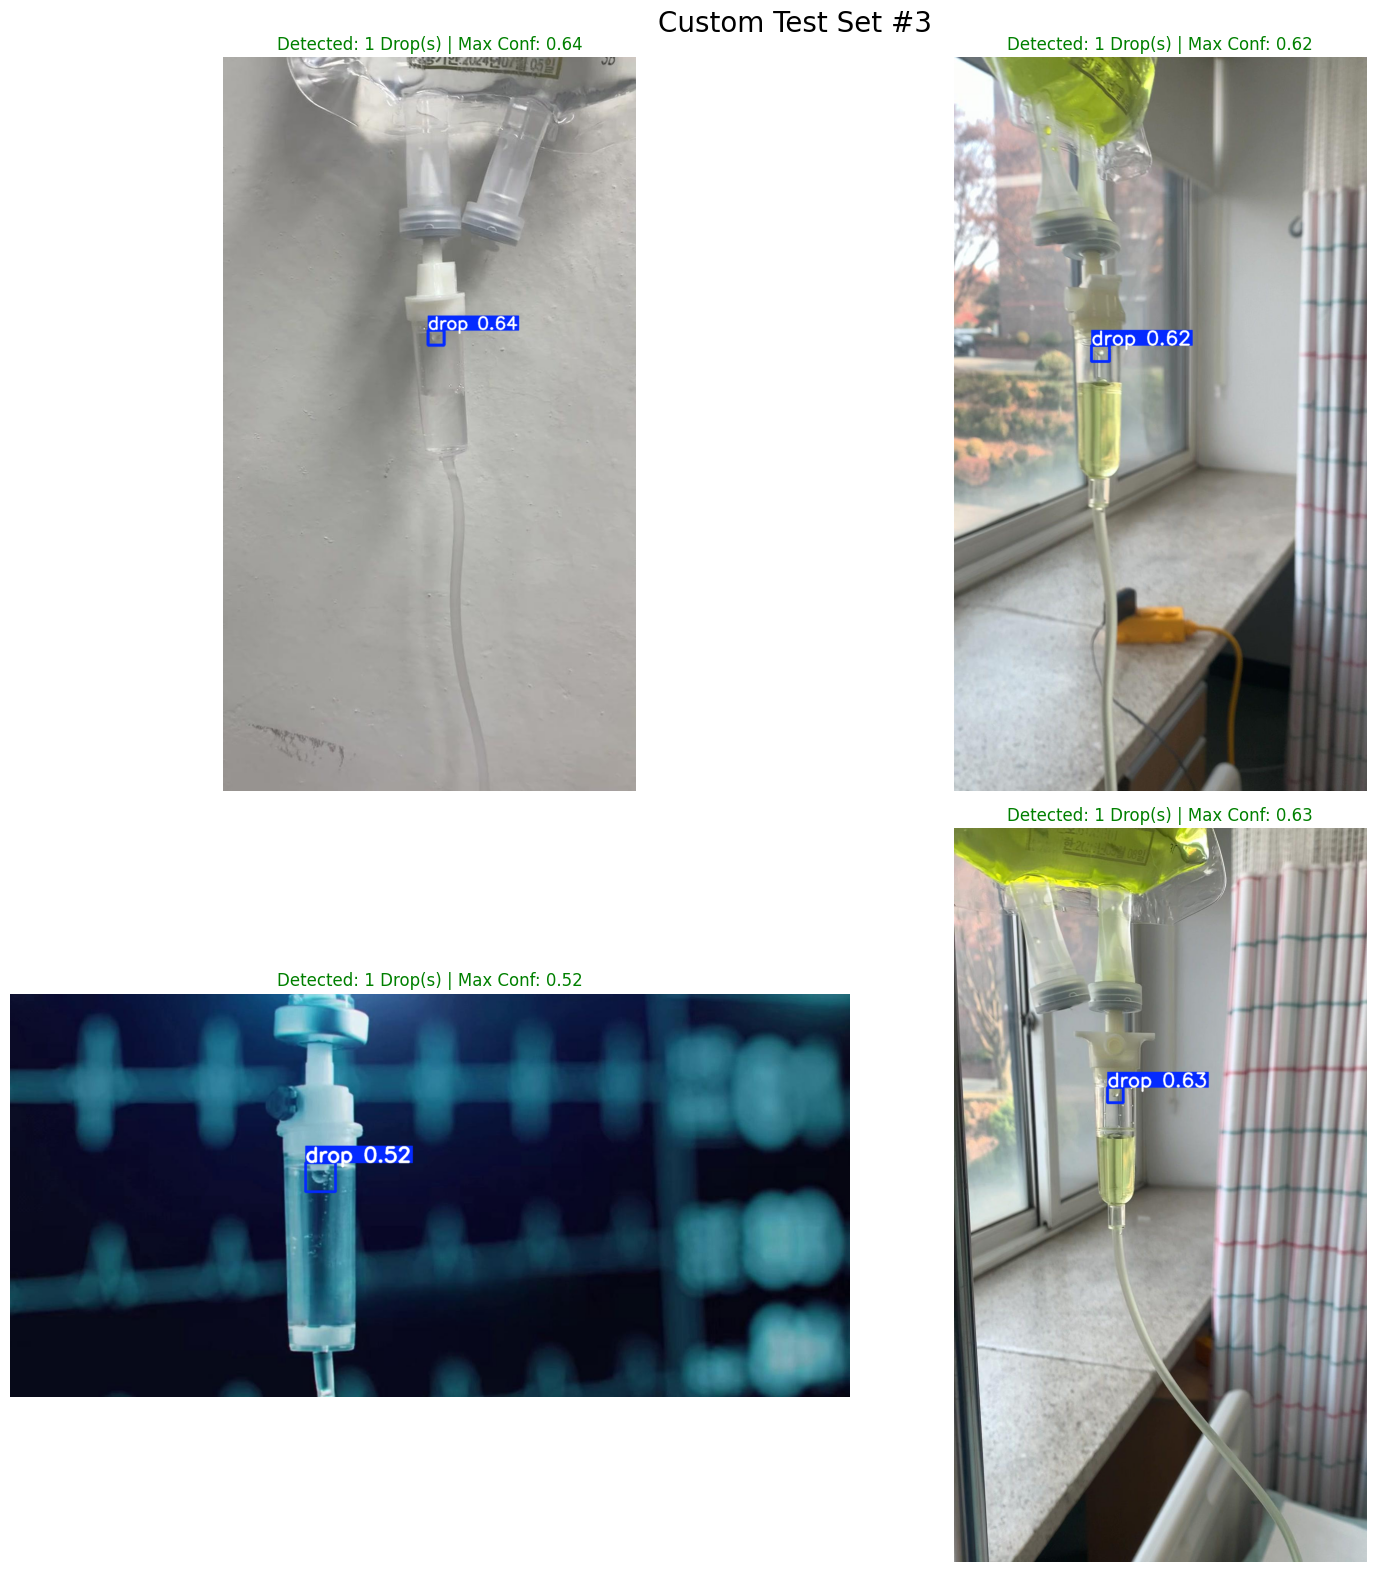

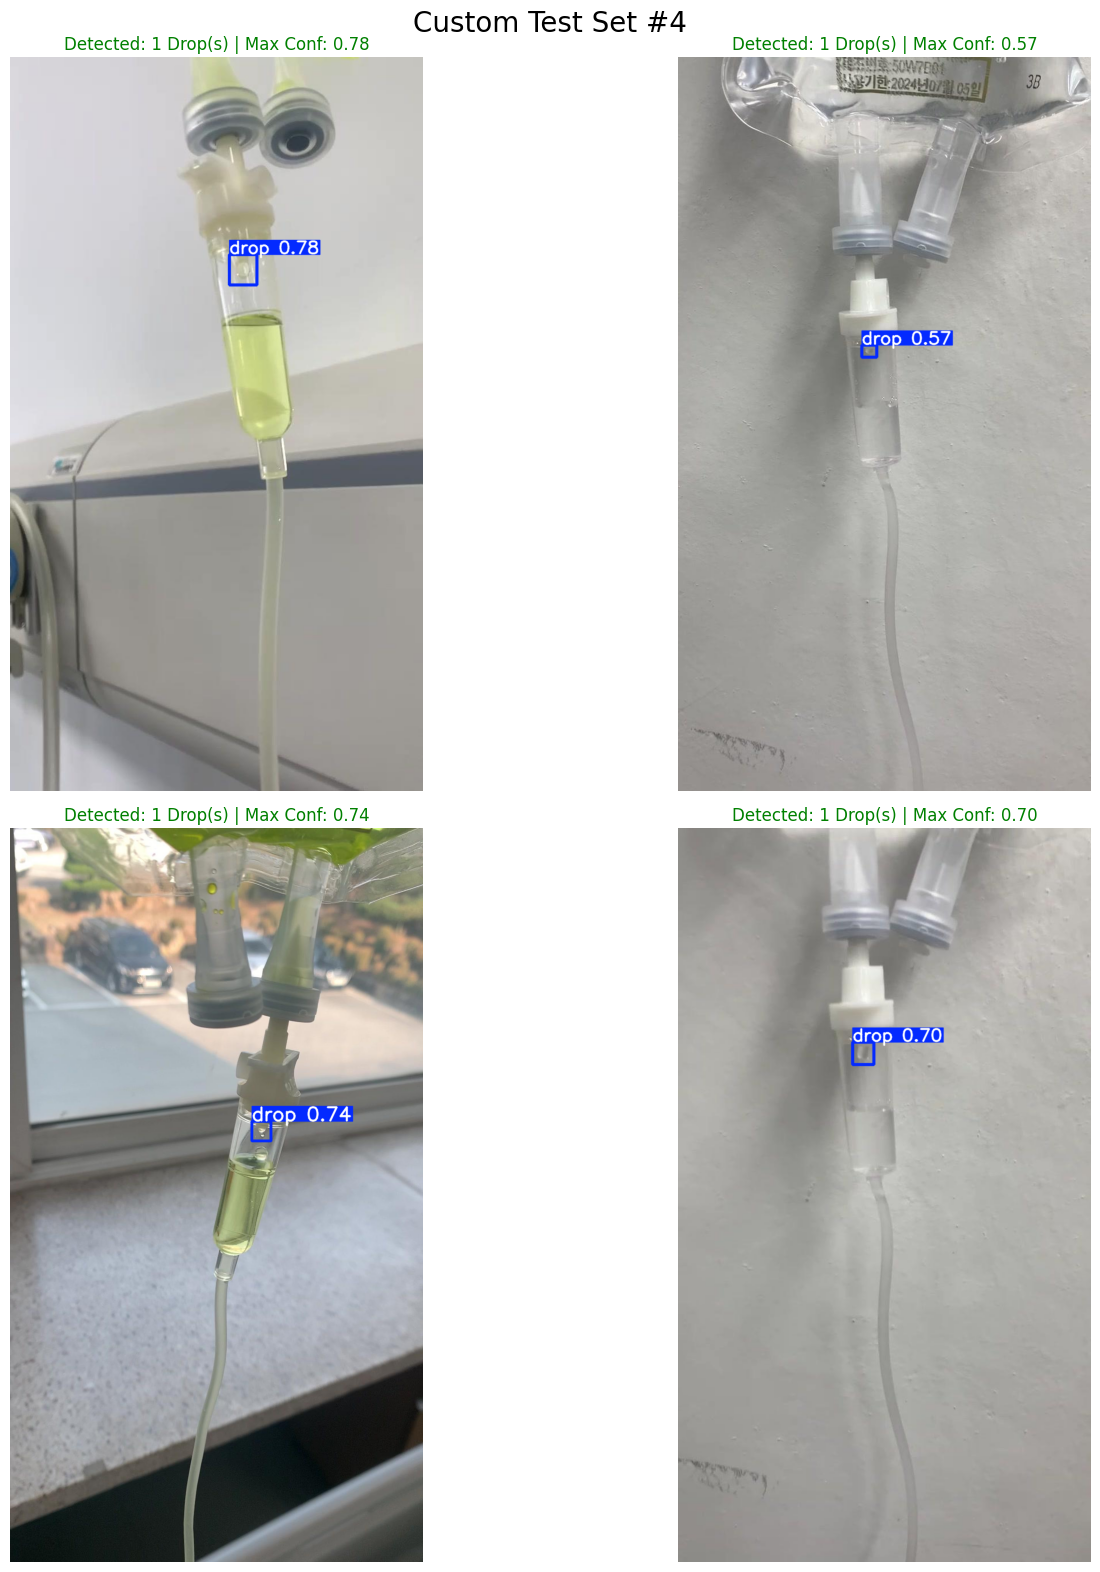

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob
import os
import random
import cv2
import math
from ultralytics import YOLO

# 1. Load the model
model = YOLO('/kaggle/working/runs/detect/drop_detection/weights/best.pt')

# Path to runs directory
runs_dir = '/kaggle/working/runs/detect/drop_detection/'

# ==============================================================================
# PART 1: Display Pre-generated Validation Batches (Batch 1 & 2 if they exist)
# ==============================================================================
print("--- Checking for extra training batches (Batch 1, Batch 2) ---")

# Find all batch label files (e.g., val_batch1_labels.jpg)
batch_label_files = sorted(glob.glob(os.path.join(runs_dir, 'val_batch*_labels.jpg')))

# Filter out batch0 since we already saw it
extra_batches = [f for f in batch_label_files if 'batch0' not in f]

if extra_batches:
    for lbl_path in extra_batches:
        # Get corresponding prediction file
        pred_path = lbl_path.replace('_labels.jpg', '_pred.jpg')
        
        if os.path.exists(pred_path):
            batch_name = os.path.basename(lbl_path).split('_labels')[0]
            
            fig, axes = plt.subplots(1, 2, figsize=(20, 10))
            
            # Plot Ground Truth
            img_lbl = mpimg.imread(lbl_path)
            axes[0].imshow(img_lbl)
            axes[0].set_title(f"{batch_name} - Ground Truth")
            axes[0].axis('off')
            
            # Plot Prediction
            img_pred = mpimg.imread(pred_path)
            axes[1].imshow(img_pred)
            axes[1].set_title(f"{batch_name} - Predictions")
            axes[1].axis('off')
            
            plt.show()
else:
    print("No additional pre-generated batches found (YOLO usually only saves the first 3).")
    print("Generating custom test sets below...\n")

# ==============================================================================
# PART 2: Generate Custom Test Sets (4 Sets of 4 Images)
# ==============================================================================
print("--- Generating Custom Test Sets on Unseen Validation Data ---")

# Get list of all validation images
val_img_dir = '/kaggle/working/dataset_split/val/images'
all_val_images = glob.glob(os.path.join(val_img_dir, '*'))

# Shuffle to ensure randomness
random.seed(42)
random.shuffle(all_val_images)

# We want 4 sets
num_sets = 4
images_per_set = 4

# Ensure we have enough images
if len(all_val_images) < num_sets * images_per_set:
    print(f"Not enough validation images for {num_sets} sets. Showing what we have.")
    num_sets = len(all_val_images) // images_per_set

for i in range(num_sets):
    # Slice a batch of images
    start_idx = i * images_per_set
    end_idx = start_idx + images_per_set
    batch_paths = all_val_images[start_idx:end_idx]
    
    # Run Inference
    results = model.predict(batch_paths, conf=0.35, verbose=False)
    
    # Create a 2x2 Grid for this set
    fig, axes = plt.subplots(2, 2, figsize=(16, 16))
    fig.suptitle(f'Custom Test Set #{i+1}', fontsize=20)
    
    axes = axes.flatten()
    
    for idx, result in enumerate(results):
        # Plot result
        im_bgr = result.plot() # Returns BGR numpy array
        im_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)
        
        # Display
        axes[idx].imshow(im_rgb)
        
        # Add title based on detection
        if len(result.boxes) > 0:
            count = len(result.boxes)
            conf = result.boxes.conf[0].item()
            axes[idx].set_title(f"Detected: {count} Drop(s) | Max Conf: {conf:.2f}", color='green', fontsize=12)
        else:
            axes[idx].set_title("No Drops Detected", color='red', fontsize=12)
            
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

### 7. Random Sample Testing

This cell performs inference on randomly selected validation images to demonstrate the model's detection capabilities.

**Process:**
- Randomly samples 5 images from the validation set.
- Runs inference with a confidence threshold of 0.25.
- Displays each image with detection results overlaid.

**Output:**
- Shows bounding boxes around detected drops.
- Displays confidence scores for each detection.
- Indicates whether drops were detected or not.
- Provides a quick sanity check of model performance.

This quick test helps verify that the model is working correctly and provides intuitive visual feedback on detection quality.


Testing on 5 images...


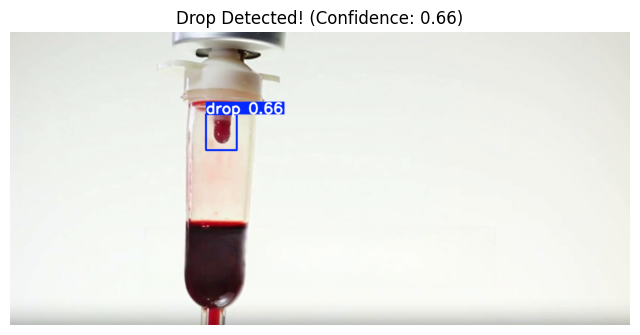

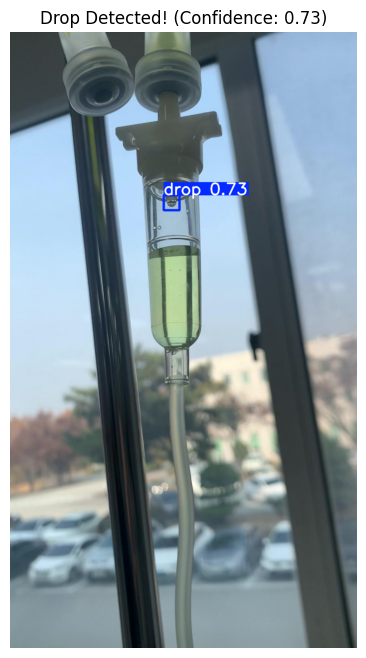

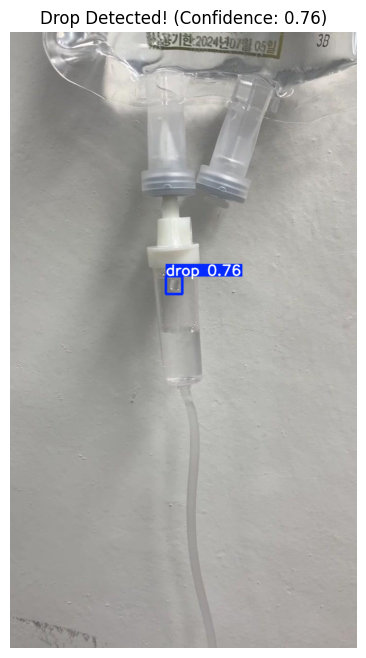

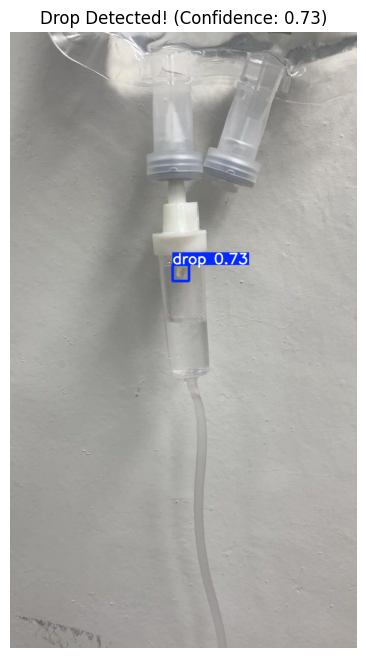

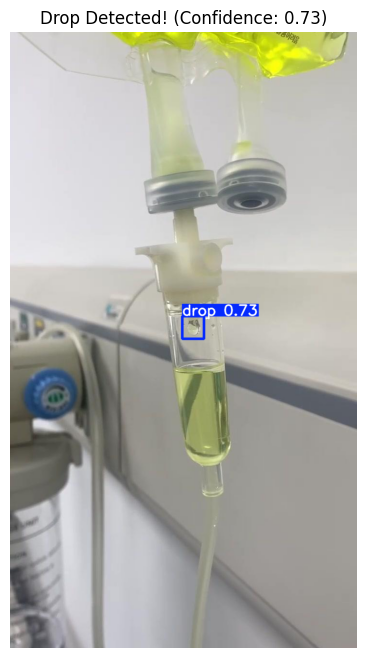

In [7]:
import random
import cv2

# Directory of validation images
val_img_dir = '/kaggle/working/dataset_split/val/images'
val_images = glob.glob(os.path.join(val_img_dir, '*'))

# Pick 5 random images
test_samples = random.sample(val_images, min(5, len(val_images)))

print(f"Testing on {len(test_samples)} images...")

results = model.predict(test_samples, conf=0.25) # Confidence threshold 0.25

for r in results:
    # Plot the result
    im_array = r.plot()  # plot() returns a BGR numpy array
    
    # Convert BGR to RGB
    im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(im_rgb)
    
    # Check if boxes were detected
    if len(r.boxes) > 0:
        conf = r.boxes.conf[0].item()
        plt.title(f"Drop Detected! (Confidence: {conf:.2f})")
    else:
        plt.title("No Drop Detected")
        
    plt.axis('off')
    plt.show()

### 8. Performance Metrics Summary

This cell computes and displays comprehensive performance metrics on the validation set in a structured table format.

**Metrics Calculated:**
- **Precision (Correctness):** When the model predicts a drop, how often is it correct? Measures false positive rate.
- **Recall (Completeness):** Out of all actual drops, what percentage did the model find? Measures false negative rate.
- **mAP@50 (Standard Accuracy):** Mean Average Precision at IoU threshold of 0.5. Standard metric for object detection accuracy.
- **mAP@50-95 (High Precision Accuracy):** Mean Average Precision averaged over IoU thresholds from 0.5 to 0.95. More stringent metric requiring better box alignment.
- **F1 Score (Overall Balance):** Harmonic mean of precision and recall. Provides a single balanced performance metric.

**Process:**
- Runs validation on the validation set.
- Extracts metrics from YOLOv8's validation results.
- Formats metrics as percentages for easy interpretation.
- Displays in a clean table with descriptions.

These metrics provide objective, quantitative measures of model performance for comparison with other models or iterations.


In [8]:
import pandas as pd
from ultralytics import YOLO
from IPython.display import display

# 1. Load the trained model
model = YOLO('/kaggle/working/runs/detect/drop_detection/weights/best.pt')

# 2. Run validation to fetch the latest metrics
print("Calculating metrics on validation set...")
metrics = model.val(verbose=False)

# 3. Extract the key numbers
# precision: How accurate are the positive predictions?
# recall: How many of the actual drops did we find?
precision = metrics.box.mp
recall = metrics.box.mr
map50 = metrics.box.map50
map50_95 = metrics.box.map

# Calculate F1 Score (Harmonic mean of Precision and Recall)
f1_score = 2 * (precision * recall) / (precision + recall)

# 4. Create a Dataframe for the table
data = {
    "Metric": [
        "Precision (Correctness)", 
        "Recall (Completeness)", 
        "mAP@50 (Standard Accuracy)", 
        "mAP@50-95 (High Precision Accuracy)",
        "F1 Score (Overall Balance)"
    ],
    "Value": [precision, recall, map50, map50_95, f1_score],
    "Description": [
        "When the model predicts a drop, how often is it right?",
        "Out of all actual drops, what % did the model find?",
        "Accuracy where the box overlaps at least 50% with truth.",
        "Strict accuracy. Requires the box to align perfectly.",
        "A combined score. Closer to 100% is better."
    ]
}

df = pd.DataFrame(data)

# 5. Format the values as Percentages
df['Value'] = df['Value'].apply(lambda x: f"{x*100:.2f}%")

# Display the table
print("\n=== FINAL PERFORMANCE TABLE ===")
display(df)

Calculating metrics on validation set...
Ultralytics 8.3.234 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1375.5±879.2 MB/s, size: 61.1 KB)
val: Scanning /kaggle/working/dataset_split/val/labels.cache... 692 images, 73 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 692/692 1.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 44/44 9.9it/s 4.4s


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        692        619      0.944      0.937      0.957      0.506
Speed: 0.6ms preprocess, 2.2ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

=== FINAL PERFORMANCE TABLE ===


,Metric,Value,Description
0,Precision (Correctness),94.40%,"When the model predicts a drop, how often is i..."
1,Recall (Completeness),93.70%,"Out of all actual drops, what % did the model ..."
2,mAP@50 (Standard Accuracy),95.75%,Accuracy where the box overlaps at least 50% w...
3,mAP@50-95 (High Precision Accuracy),50.61%,Strict accuracy. Requires the box to align per...
4,F1 Score (Overall Balance),94.05%,A combined score. Closer to 100% is better.


### 9. Comprehensive Performance Analysis and Visualization

This cell generates extensive visualizations and analyses of the model's training and performance.

**Analysis Components:**
1. **Confusion Matrix:** Raw counts showing TP, FP, TN, FN.
2. **Training Loss Over Epochs:** Box loss, classification loss, and DFL loss curves showing training convergence.
3. **Validation Loss Over Epochs:** Validation loss components to identify overfitting.
4. **Precision, Recall, and mAP Over Epochs:** Tracking performance metrics throughout training.
5. **Learning Rate Schedule:** Shows how learning rate was adjusted during training.
6. **F1-Confidence Curve:** Analyzes F1-score at different confidence thresholds to find optimal threshold.
7. **Auto-generated Plots:** Displays all plots automatically generated by YOLOv8 during training (results, confusion matrix, curves).

**Benefits:**
- Comprehensive understanding of model performance.
- Identification of optimal confidence thresholds for deployment.
- Insights into training dynamics and convergence.
- Visual documentation for reports or presentations.

These visualizations help make informed decisions about model deployment, threshold selection, and potential improvements.


Generating Confusion Matrix...
Ultralytics 8.3.234 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1950.5±1244.1 MB/s, size: 96.2 KB)
val: Scanning /kaggle/working/dataset_split/val/labels.cache... 692 images, 73 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 692/692 1.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 44/44 10.1it/s 4.4s


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        692        619      0.944      0.937      0.957      0.506
Speed: 0.6ms preprocess, 2.1ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /kaggle/working/runs/detect/val2


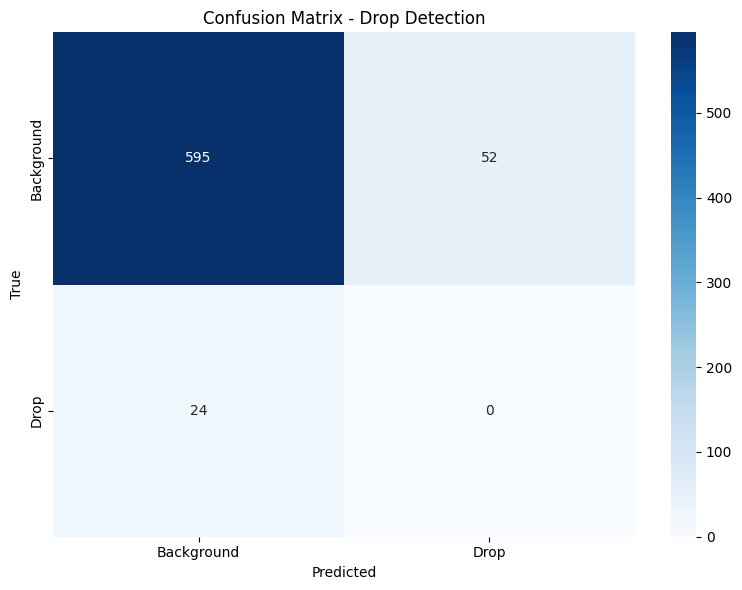

Generating Loss Plots...


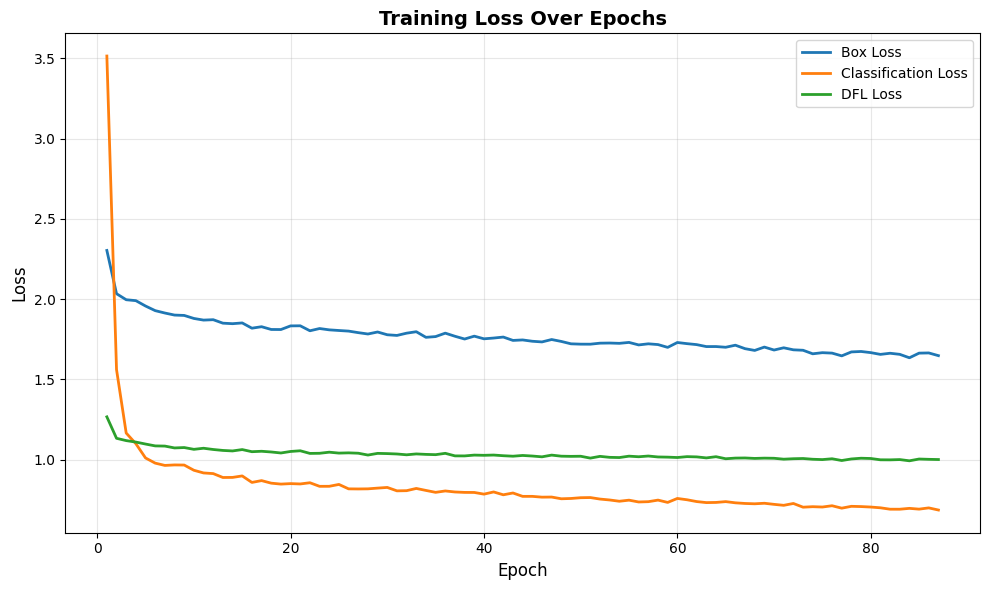

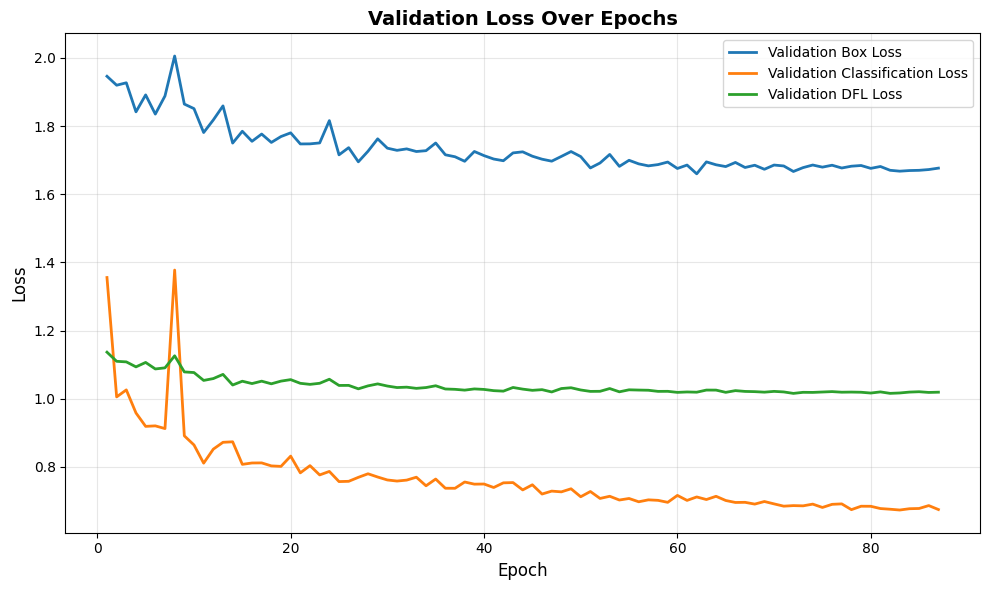

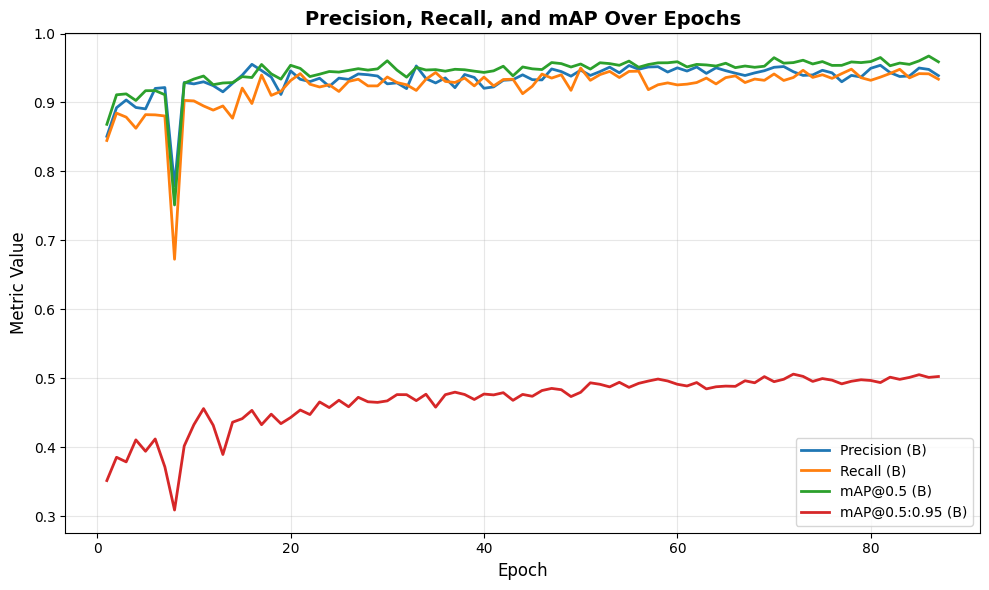

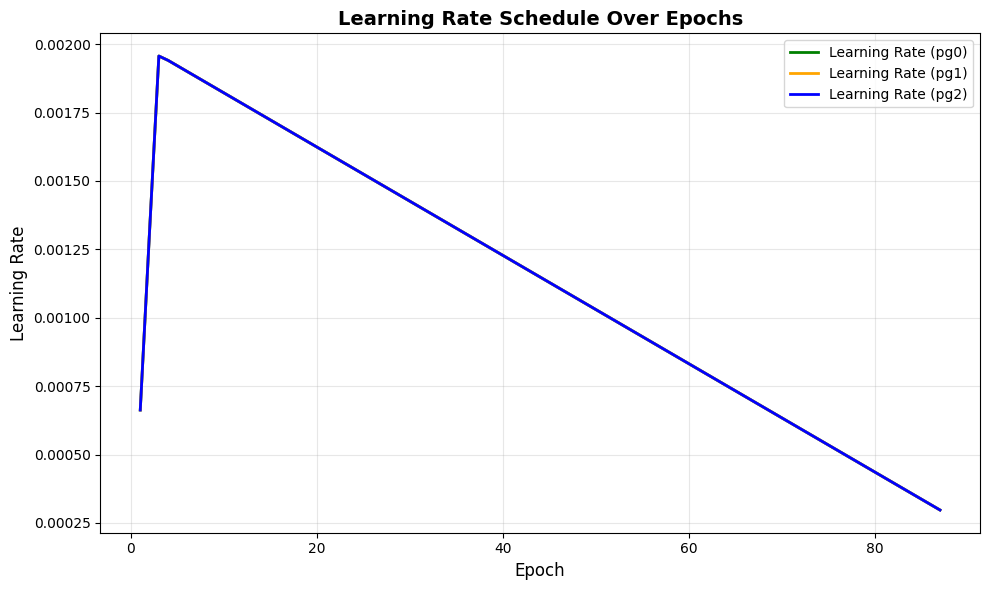

Generating F1-Confidence Curve...


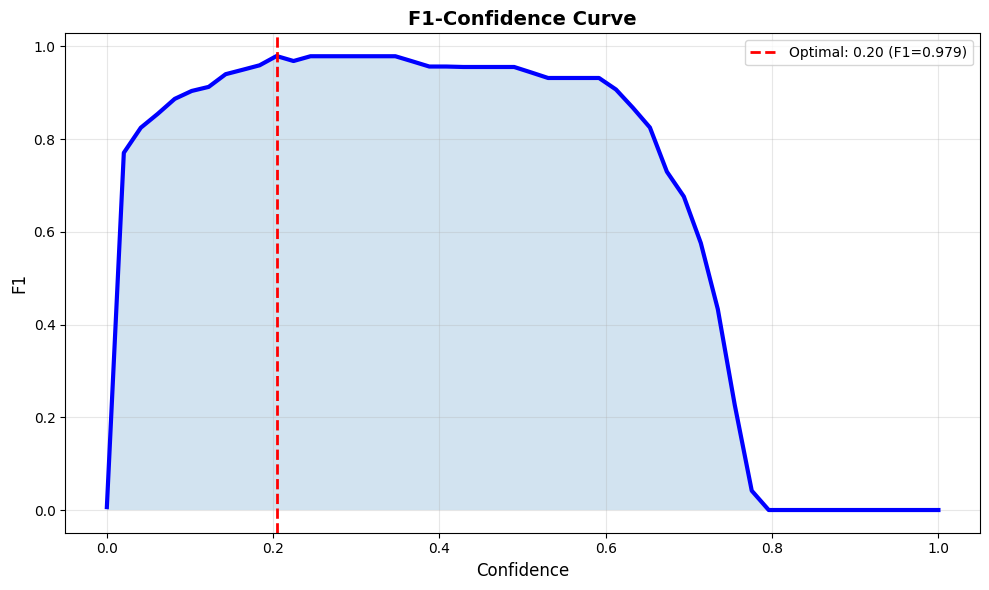


✅ All plots saved!
📊 Optimal confidence threshold: 0.20 with F1=0.979

Generating PR Curve...
PR Curve not found - it's auto-generated during training in the results folder

AUTO-GENERATED PLOTS FROM TRAINING:
✅ results.png: /kaggle/working/runs/detect/drop_detection/results.png


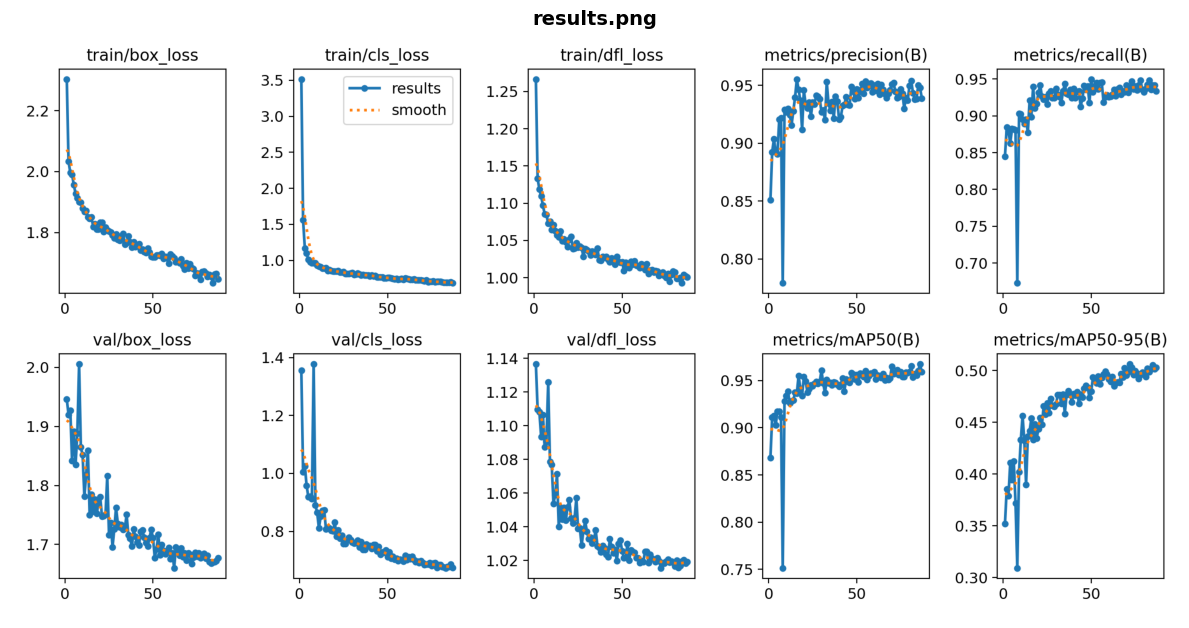

✅ confusion_matrix.png: /kaggle/working/runs/detect/drop_detection/confusion_matrix.png


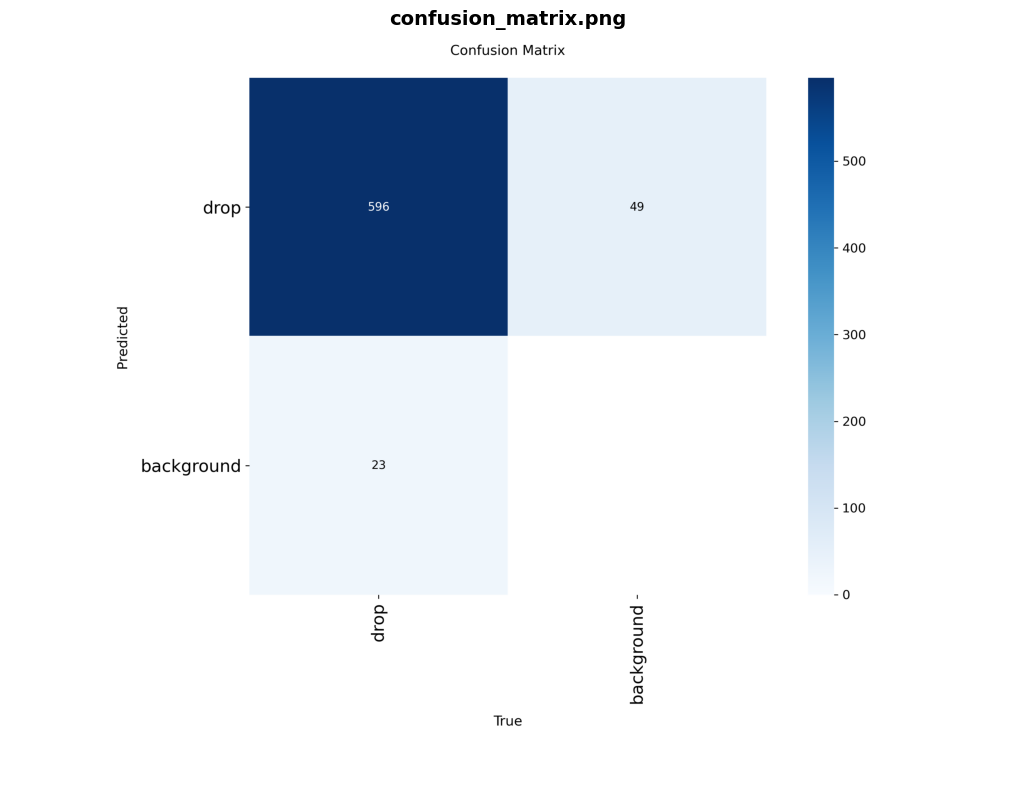

❌ F1_curve.png: Not found
❌ P_curve.png: Not found
❌ R_curve.png: Not found
❌ PR_curve.png: Not found

✅ All visualizations complete!


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from glob import glob
import cv2

# =============================================================================
# LOAD TRAINED MODEL
# =============================================================================
# Use the best weights from your training
model = YOLO('/kaggle/working/runs/detect/drop_detection/weights/best.pt')

# =============================================================================
# 1. CONFUSION MATRIX
# =============================================================================
print("Generating Confusion Matrix...")

# Run validation to get metrics
results = model.val(data='/kaggle/working/data.yaml')

# Get confusion matrix (if available from results)
# Note: YOLO's confusion matrix is for detection, showing TP, FP, FN
if hasattr(results, 'confusion_matrix'):
    cm = results.confusion_matrix.matrix
    
    plt.figure(figsize=(8, 6))
    labels = ['Background', 'Drop']
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix - Drop Detection')
    plt.tight_layout()
    plt.savefig('/kaggle/working/confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

# =============================================================================
# 2. TRAINING & VALIDATION LOSS PLOTS
# =============================================================================
print("Generating Loss Plots...")

# Read results from CSV file generated during training
import pandas as pd

results_csv = '/kaggle/working/runs/detect/drop_detection/results.csv'
if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()  # Clean column names
    
    # (a) Training Loss Over Epochs
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(df['epoch'], df['train/box_loss'], label='Box Loss', linewidth=2)
    ax.plot(df['epoch'], df['train/cls_loss'], label='Classification Loss', linewidth=2)
    ax.plot(df['epoch'], df['train/dfl_loss'], label='DFL Loss', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Training Loss Over Epochs', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/kaggle/working/training_loss.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # (b) Validation Loss Over Epochs
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(df['epoch'], df['val/box_loss'], label='Validation Box Loss', linewidth=2)
    ax.plot(df['epoch'], df['val/cls_loss'], label='Validation Classification Loss', linewidth=2)
    ax.plot(df['epoch'], df['val/dfl_loss'], label='Validation DFL Loss', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Validation Loss Over Epochs', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/kaggle/working/validation_loss.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # (c) Precision, Recall, and mAP Over Epochs
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(df['epoch'], df['metrics/precision(B)'], label='Precision (B)', linewidth=2)
    ax.plot(df['epoch'], df['metrics/recall(B)'], label='Recall (B)', linewidth=2)
    ax.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@0.5 (B)', linewidth=2)
    ax.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95 (B)', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Metric Value', fontsize=12)
    ax.set_title('Precision, Recall, and mAP Over Epochs', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/kaggle/working/metrics_over_epochs.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # (d) Learning Rate Schedule
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(df['epoch'], df['lr/pg0'], label='Learning Rate (pg0)', linewidth=2, color='green')
    ax.plot(df['epoch'], df['lr/pg1'], label='Learning Rate (pg1)', linewidth=2, color='orange')
    ax.plot(df['epoch'], df['lr/pg2'], label='Learning Rate (pg2)', linewidth=2, color='blue')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Learning Rate', fontsize=12)
    ax.set_title('Learning Rate Schedule Over Epochs', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/kaggle/working/learning_rate.png', dpi=300, bbox_inches='tight')
    plt.show()

# =============================================================================
# 3. F1-CONFIDENCE CURVE
# =============================================================================
print("Generating F1-Confidence Curve...")

# Calculate F1 scores at different confidence thresholds
val_images = glob(os.path.join(WORKING_DIR, 'val', 'images', '*'))
confidences = np.linspace(0.0, 1.0, 50)
f1_scores = []

for conf in confidences:
    tp, fp, fn = 0, 0, 0
    
    for img_path in val_images[:50]:  # Sample for speed
        # Get predictions
        results = model.predict(img_path, conf=conf, verbose=False)
        
        # Get ground truth
        label_path = img_path.replace('images', 'labels').replace(
            os.path.splitext(img_path)[1], '.txt'
        )
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                gt_boxes = len(f.readlines())
        else:
            gt_boxes = 0
        
        pred_boxes = len(results[0].boxes) if results[0].boxes is not None else 0
        
        # Simple TP/FP/FN calculation
        tp += min(pred_boxes, gt_boxes)
        fp += max(0, pred_boxes - gt_boxes)
        fn += max(0, gt_boxes - pred_boxes)
    
    # Calculate F1
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    f1_scores.append(f1)

# (e) Plot F1-Confidence Curve
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(confidences, f1_scores, linewidth=3, color='blue')
ax.fill_between(confidences, f1_scores, alpha=0.2)

# Find optimal confidence threshold
optimal_idx = np.argmax(f1_scores)
optimal_conf = confidences[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

ax.axvline(optimal_conf, color='red', linestyle='--', linewidth=2, 
           label=f'Optimal: {optimal_conf:.2f} (F1={optimal_f1:.3f})')
ax.set_xlabel('Confidence', fontsize=12)
ax.set_ylabel('F1', fontsize=12)
ax.set_title('F1-Confidence Curve', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/f1_confidence_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ All plots saved!")
print(f"📊 Optimal confidence threshold: {optimal_conf:.2f} with F1={optimal_f1:.3f}")

# =============================================================================
# 4. BONUS: PR CURVE (Precision-Recall)
# =============================================================================
print("\nGenerating PR Curve...")

# Check if PR curve exists in results
pr_curve_path = '/kaggle/working/runs/detect/drop_detection/PR_curve.png'
if os.path.exists(pr_curve_path):
    print(f"PR Curve already saved at: {pr_curve_path}")
else:
    print("PR Curve not found - it's auto-generated during training in the results folder")

# =============================================================================
# 5. DISPLAY ALL AUTO-GENERATED PLOTS FROM TRAINING
# =============================================================================
print("\n" + "="*80)
print("AUTO-GENERATED PLOTS FROM TRAINING:")
print("="*80)

plots_dir = '/kaggle/working/runs/detect/drop_detection'
plot_files = [
    'results.png',           # Combined metrics plot
    'confusion_matrix.png',  # Confusion matrix (if generated)
    'F1_curve.png',         # F1 curve
    'P_curve.png',          # Precision curve
    'R_curve.png',          # Recall curve
    'PR_curve.png',         # Precision-Recall curve
]

for plot_file in plot_files:
    plot_path = os.path.join(plots_dir, plot_file)
    if os.path.exists(plot_path):
        print(f"✅ {plot_file}: {plot_path}")
        
        # Display the plot
        img = plt.imread(plot_path)
        plt.figure(figsize=(12, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(plot_file, fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print(f"❌ {plot_file}: Not found")

print("\n✅ All visualizations complete!")

### 10. Model Artifacts Export

After training and evaluation, this cell packages all important model artifacts into a single ZIP file for easy download and deployment.

**Exported Files:**
- **best.pt:** The best model checkpoint (lowest validation loss).
- **last.pt:** The final model checkpoint after training completion.
- **results.csv:** Complete training history with all metrics per epoch.
- **data.yaml:** Dataset configuration file for reproducibility.

**Use Cases:**
- Model deployment in production systems.
- Sharing trained models with team members.
- Reproducing results or continuing training later.
- Creating backups of trained models.

The ZIP file can be downloaded from Kaggle's output tab and used for inference in other environments or applications.


In [10]:
# QUICK KAGGLE DOWNLOAD
import shutil
import zipfile
import os

# Create ZIP with everything
zip_path = '/kaggle/working/drop_detection_complete.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    # Add model weights
    zipf.write('/kaggle/working/runs/detect/drop_detection/weights/best.pt', 'best.pt')
    zipf.write('/kaggle/working/runs/detect/drop_detection/weights/last.pt', 'last.pt')
    
    # Add results
    zipf.write('/kaggle/working/runs/detect/drop_detection/results.csv', 'results.csv')
    
    # Add data config
    zipf.write('/kaggle/working/data.yaml', 'data.yaml')

print(f"✅ Created: {zip_path}")
print(f"📦 Size: {os.path.getsize(zip_path) / 1_000_000:.2f} MB")
print("\n📥 TO DOWNLOAD:")
print("1. Click 'Save Version' (top-right)")
print("2. Wait for it to complete")
print("3. Go to 'Output' tab")
print("4. Download 'drop_detection_complete.zip'")

✅ Created: /kaggle/working/drop_detection_complete.zip
📦 Size: 11.34 MB

📥 TO DOWNLOAD:
1. Click 'Save Version' (top-right)
2. Wait for it to complete
3. Go to 'Output' tab
4. Download 'drop_detection_complete.zip'


### 11. Detailed Confusion Matrix Analysis

This cell provides an in-depth analysis of the confusion matrix with multiple visualization formats and detailed metrics.

**Analysis Components:**
- **Raw Confusion Matrix:** Shows actual counts of TP, TN, FP, FN.
- **Normalized Confusion Matrix:** Shows percentages normalized by true labels for easier interpretation.
- **Side-by-Side Comparison:** Displays both raw and normalized matrices together for comprehensive understanding.
- **Detailed Metrics Breakdown:**
    - True Positives (TP): Correctly detected drops.
    - True Negatives (TN): Correctly identified background/no-drop images.
    - False Positives (FP): Background incorrectly identified as drops.
    - False Negatives (FN): Drops that were missed.
    - Accuracy, Precision, Recall, F1-Score, and Specificity.

**Interpretation:**
- Helps understand model behavior in detail.
- Identifies specific types of errors (false positives vs. false negatives).
- Guides decision-making about threshold adjustment.
- Provides metrics for comparing model versions or configurations.

This comprehensive analysis is essential for understanding model performance at a granular level and making informed decisions about deployment configurations.


Generating Confusion Matrix (Raw Counts)...
Ultralytics 8.3.234 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1827.4±1000.7 MB/s, size: 84.3 KB)
val: Scanning /kaggle/working/dataset_split/val/labels.cache... 692 images, 73 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 692/692 1.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 44/44 10.2it/s 4.3s


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        692        619      0.944      0.937      0.957      0.506
Speed: 0.6ms preprocess, 2.1ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /kaggle/working/runs/detect/val3


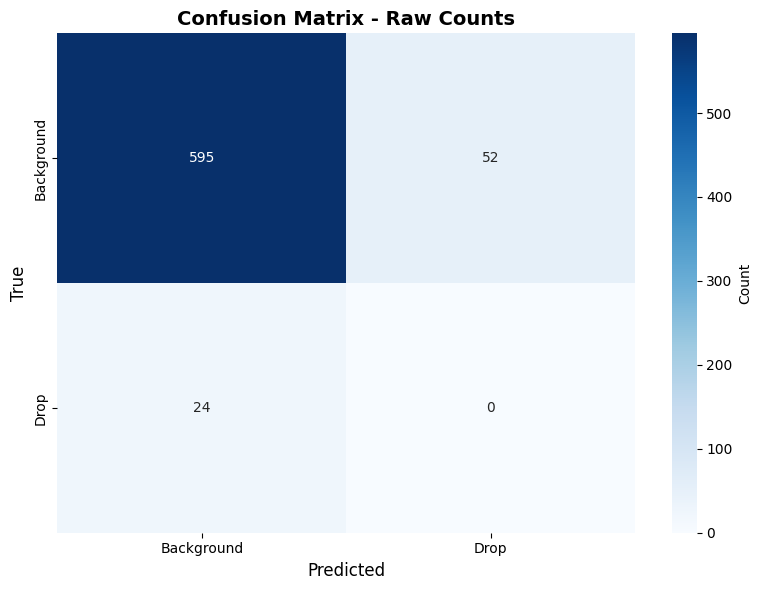

Raw Confusion Matrix:
[[        595          52]
 [         24           0]]

Generating Confusion Matrix (Normalized)...


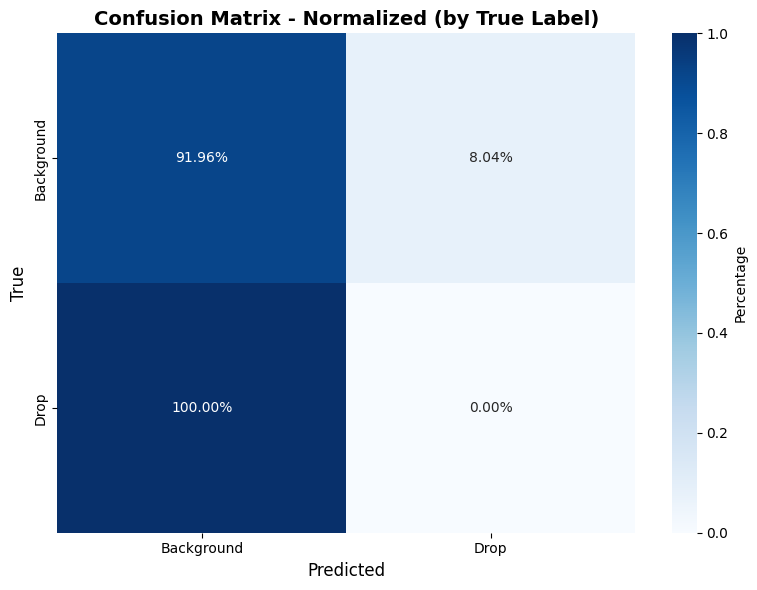

Normalized Confusion Matrix:
[[    0.91963    0.080371]
 [          1           0]]

Generating Side-by-Side Comparison...


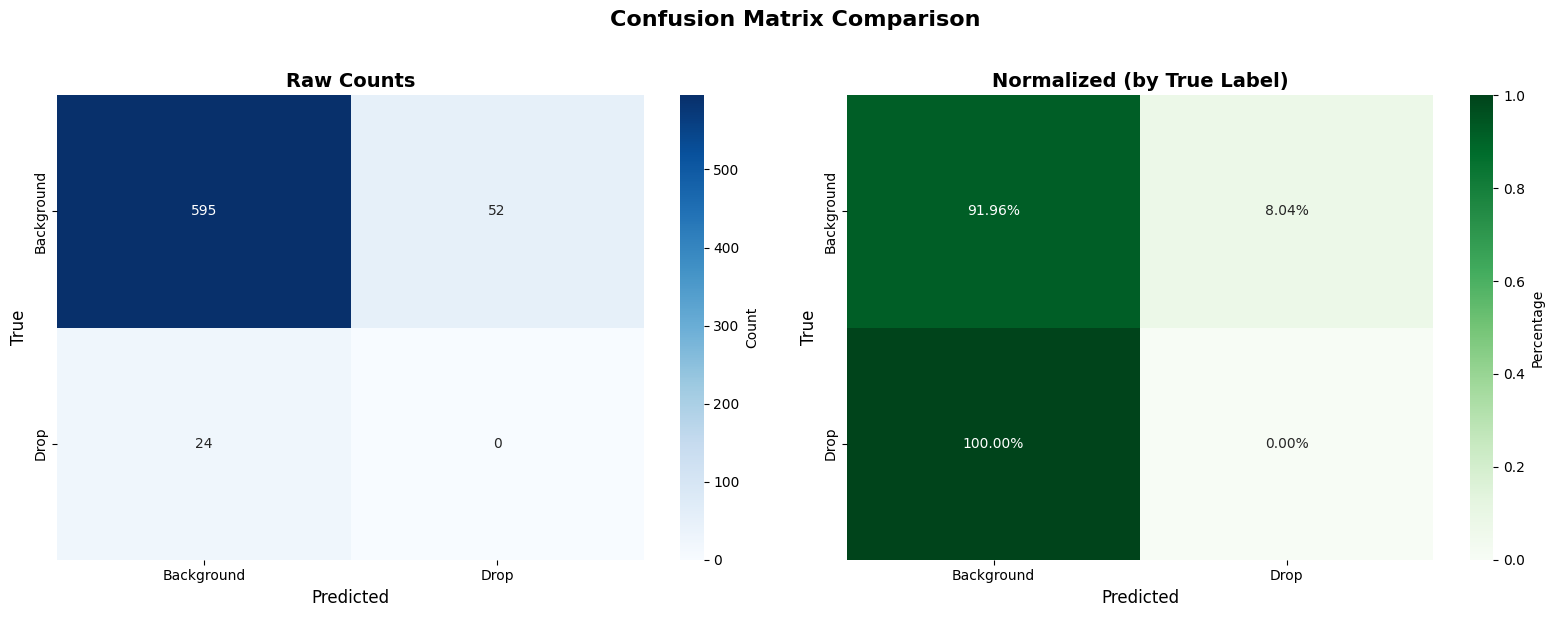


📊 CONFUSION MATRIX METRICS
True Positives (TP):        0  (Drop detected correctly)
True Negatives (TN):      595  (Background detected correctly)
False Positives (FP):      52  (Background misclassified as Drop)
False Negatives (FN):      24  (Drop missed)
------------------------------------------------------------
Accuracy:              88.67%
Precision:              0.00%  (When predicted Drop, how often correct?)
Recall (Sensitivity):   0.00%  (Of all actual Drops, how many detected?)
F1-Score:               0.00%  (Harmonic mean of Precision & Recall)
Specificity:           91.96%  (Of all Backgrounds, how many correct?)


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO
import seaborn as sns

# =============================================================================
# LOAD TRAINED MODEL
# =============================================================================
model = YOLO('/kaggle/working/runs/detect/drop_detection/weights/best.pt')

# =============================================================================
# CONFUSION MATRIX - NON-NORMALIZED (RAW COUNTS)
# =============================================================================
print("Generating Confusion Matrix (Raw Counts)...")

# Run validation to get metrics
results = model.val(data='/kaggle/working/data.yaml')

# Get confusion matrix
if hasattr(results, 'confusion_matrix'):
    cm = results.confusion_matrix.matrix
    
    plt.figure(figsize=(8, 6))
    labels = ['Background', 'Drop']
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
                xticklabels=labels, yticklabels=labels,
                cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('True', fontsize=12)
    plt.title('Confusion Matrix - Raw Counts', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/kaggle/working/confusion_matrix_raw.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Raw Confusion Matrix:\n{cm}\n")

# =============================================================================
# CONFUSION MATRIX - NORMALIZED (PERCENTAGES)
# =============================================================================
print("Generating Confusion Matrix (Normalized)...")

if hasattr(results, 'confusion_matrix'):
    cm = results.confusion_matrix.matrix
    
    # Normalize by row (by true label)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(8, 6))
    labels = ['Background', 'Drop']
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', 
                xticklabels=labels, yticklabels=labels,
                cbar_kws={'label': 'Percentage'},
                vmin=0, vmax=1)
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('True', fontsize=12)
    plt.title('Confusion Matrix - Normalized (by True Label)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/kaggle/working/confusion_matrix_normalized.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Normalized Confusion Matrix:\n{cm_normalized}\n")

# =============================================================================
# BOTH SIDE-BY-SIDE
# =============================================================================
print("Generating Side-by-Side Comparison...")

if hasattr(results, 'confusion_matrix'):
    cm = results.confusion_matrix.matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    labels = ['Background', 'Drop']
    
    # Raw counts
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
                xticklabels=labels, yticklabels=labels,
                ax=axes[0], cbar_kws={'label': 'Count'})
    axes[0].set_xlabel('Predicted', fontsize=12)
    axes[0].set_ylabel('True', fontsize=12)
    axes[0].set_title('Raw Counts', fontsize=14, fontweight='bold')
    
    # Normalized percentages
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens', 
                xticklabels=labels, yticklabels=labels,
                ax=axes[1], cbar_kws={'label': 'Percentage'}, vmin=0, vmax=1)
    axes[1].set_xlabel('Predicted', fontsize=12)
    axes[1].set_ylabel('True', fontsize=12)
    axes[1].set_title('Normalized (by True Label)', fontsize=14, fontweight='bold')
    
    plt.suptitle('Confusion Matrix Comparison', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('/kaggle/working/confusion_matrix_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# =============================================================================
# DETAILED METRICS FROM CONFUSION MATRIX
# =============================================================================
if hasattr(results, 'confusion_matrix'):
    cm = results.confusion_matrix.matrix
    
    # Extract values (for binary classification)
    TN = cm[0, 0]  # True Negative (Background correctly classified)
    FP = cm[0, 1]  # False Positive (Background predicted as Drop)
    FN = cm[1, 0]  # False Negative (Drop predicted as Background)
    TP = cm[1, 1]  # True Positive (Drop correctly classified)
    
    # Calculate metrics
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    
    print("\n" + "="*60)
    print("📊 CONFUSION MATRIX METRICS")
    print("="*60)
    print(f"True Positives (TP):   {TP:>6.0f}  (Drop detected correctly)")
    print(f"True Negatives (TN):   {TN:>6.0f}  (Background detected correctly)")
    print(f"False Positives (FP):  {FP:>6.0f}  (Background misclassified as Drop)")
    print(f"False Negatives (FN):  {FN:>6.0f}  (Drop missed)")
    print("-" * 60)
    print(f"Accuracy:              {accuracy:>6.2%}")
    print(f"Precision:             {precision:>6.2%}  (When predicted Drop, how often correct?)")
    print(f"Recall (Sensitivity):  {recall:>6.2%}  (Of all actual Drops, how many detected?)")
    print(f"F1-Score:              {f1_score:>6.2%}  (Harmonic mean of Precision & Recall)")
    print(f"Specificity:           {specificity:>6.2%}  (Of all Backgrounds, how many correct?)")
    print("="*60)